In [1]:
# Full MP4 video
# → sample frames
# → MediaPipe Tasks FaceLandmarker
# → normalize landmarks
# → create 5-second overlapping windows
# → load trained BiLSTM model
# → predict score per window
# → smooth scores
# → assign risk level
# → save timeline JSON/CSV

In [2]:
!pip install mediapipe opencv-python tensorflow pandas numpy matplotlib tqdm

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl (351.2 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import json
import cv2
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
from tqdm import tqdm

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

In [2]:
from pathlib import Path

# Current notebook location should be: staging/Video Model
CURRENT_DIR = Path.cwd()

# Define the Project Root (2 levels up)
PROJECT_ROOT = CURRENT_DIR.parents[1]

# Move two levels up, then into train/
TRAIN_DIR = PROJECT_ROOT/ "train"

MODEL_DIR = TRAIN_DIR / "trained_video_model"
MODEL_PATH = MODEL_DIR / "final_video_bilstm_model.keras"

PREPARED_DATA_DIR = TRAIN_DIR / "prepared_lstm_data"
CONFIG_PATH = PREPARED_DATA_DIR / "preprocessing_config.json"

INFERENCE_OUTPUT_DIR = TRAIN_DIR / "video_inference_outputs"
INFERENCE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model path:", MODEL_PATH)
print("Config path:", CONFIG_PATH)
print("Output folder:", INFERENCE_OUTPUT_DIR)

Model path: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\train\trained_video_model\final_video_bilstm_model.keras
Config path: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\train\prepared_lstm_data\preprocessing_config.json
Output folder: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\train\video_inference_outputs


In [3]:
print("Model exists:", MODEL_PATH.exists())
print("Config exists:", CONFIG_PATH.exists())

Model exists: True
Config exists: True


In [4]:
with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

TARGET_FPS = config["target_fps"]
WINDOW_SIZE = config["window_size"]
STRIDE = config["stride"]
FEATURE_DIM = config["feature_dim"]

print("Target FPS:", TARGET_FPS)
print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)
print("Feature dimension:", FEATURE_DIM)

Target FPS: 5
Window size: 25
Stride: 10
Feature dimension: 1434


In [5]:
model = tf.keras.models.load_model(MODEL_PATH)

print("Model loaded successfully.")
model.summary()

Model loaded successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 25, 128)        │       767,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,438,789 (9.30 MB)

 Trainable params: 812,929 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,625,860 (6.20 MB)

In [6]:
MEDIAPIPE_MODEL_DIR = TRAIN_DIR / "mediapipe_models"
MEDIAPIPE_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FACE_LANDMARKER_MODEL_PATH = MEDIAPIPE_MODEL_DIR / "face_landmarker.task"

if not FACE_LANDMARKER_MODEL_PATH.exists():
    url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
    urllib.request.urlretrieve(url, FACE_LANDMARKER_MODEL_PATH)
    print("Downloaded:", FACE_LANDMARKER_MODEL_PATH)
else:
    print("Model already exists:", FACE_LANDMARKER_MODEL_PATH)

Model already exists: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\train\mediapipe_models\face_landmarker.task


In [7]:
def create_video_landmarker():
    BaseOptions = python.BaseOptions
    FaceLandmarker = vision.FaceLandmarker
    FaceLandmarkerOptions = vision.FaceLandmarkerOptions
    VisionRunningMode = vision.RunningMode

    options = FaceLandmarkerOptions(
        base_options=BaseOptions(
            model_asset_path=str(FACE_LANDMARKER_MODEL_PATH)
        ),
        running_mode=VisionRunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.25,
        min_face_presence_confidence=0.25,
        min_tracking_confidence=0.25,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False
    )

    return FaceLandmarker.create_from_options(options)

In [61]:
VIDEO_PATH = PROJECT_ROOT/ "Dataset" / "Real-life_Deception_Detection_2016" / "Clips" / "Truthful" / "trial_truth_020.mp4"

print("Video path:", VIDEO_PATH)
print("Video exists:", VIDEO_PATH.exists())

Video path: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\Dataset\Real-life_Deception_Detection_2016\Clips\Truthful\trial_truth_020.mp4
Video exists: True


In [62]:
def extract_sampled_frames(video_path, target_fps=5):
    video_path = Path(video_path)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    original_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if original_fps <= 0:
        cap.release()
        raise ValueError("Invalid original FPS.")

    frame_interval = max(int(round(original_fps / target_fps)), 1)

    sampled_frames = []
    sampled_frame_indices = []

    frame_index = 0

    while True:
        ret, frame_bgr = cap.read()

        if not ret:
            break

        if frame_index % frame_interval == 0:
            sampled_frames.append(frame_bgr)
            sampled_frame_indices.append(frame_index)

        frame_index += 1

    cap.release()

    duration_seconds = total_frames / original_fps

    metadata = {
        "original_fps": float(original_fps),
        "target_fps": target_fps,
        "total_frames": total_frames,
        "sampled_frames": len(sampled_frames),
        "duration_seconds": float(duration_seconds),
        "frame_interval": frame_interval
    }

    return sampled_frames, sampled_frame_indices, metadata

In [63]:
frames, frame_indices, video_metadata = extract_sampled_frames(
    VIDEO_PATH,
    target_fps=TARGET_FPS
)

print(video_metadata)
print("Number of sampled frames:", len(frames))

{'original_fps': 25.0, 'target_fps': 5, 'total_frames': 173, 'sampled_frames': 35, 'duration_seconds': 6.92, 'frame_interval': 5}
Number of sampled frames: 35


In [64]:
def extract_landmarks_from_frame_bgr_video_mode(frame_bgr, timestamp_ms, landmarker):
    if frame_bgr is None:
        return None

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    frame_rgb = np.ascontiguousarray(frame_rgb, dtype=np.uint8)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    result = landmarker.detect_for_video(
        mp_image,
        timestamp_ms
    )

    if not result.face_landmarks:
        return None

    face_landmarks = result.face_landmarks[0]

    landmarks = []

    for landmark in face_landmarks:
        landmarks.append([
            landmark.x,
            landmark.y,
            landmark.z
        ])

    return np.array(landmarks, dtype=np.float32)

In [65]:
def normalize_landmarks(landmarks):
    landmarks = np.array(landmarks, dtype=np.float32)

    center = np.mean(landmarks, axis=0)
    centered_landmarks = landmarks - center

    min_vals = np.min(centered_landmarks, axis=0)
    max_vals = np.max(centered_landmarks, axis=0)

    face_size = np.linalg.norm(max_vals - min_vals)

    if face_size == 0:
        return None

    normalized_landmarks = centered_landmarks / face_size

    flattened = normalized_landmarks.flatten()

    return flattened.astype(np.float32)

In [66]:
def extract_landmark_sequence_from_video(video_path, target_fps=5):
    video_path = Path(video_path)

    frames, frame_indices, metadata = extract_sampled_frames(
        video_path,
        target_fps=target_fps
    )

    original_fps = metadata["original_fps"]

    sequence = []
    valid_frame_indices = []
    missing_count = 0

    previous_timestamp_ms = -1

    # Important: create a fresh landmarker for this video.
    with create_video_landmarker() as video_landmarker:

        for frame_bgr, original_frame_index in tqdm(
            list(zip(frames, frame_indices)),
            desc=f"Extracting landmarks: {video_path.name}"
        ):
            timestamp_ms = int((original_frame_index / original_fps) * 1000)

            # MediaPipe VIDEO mode requires strictly increasing timestamps.
            if timestamp_ms <= previous_timestamp_ms:
                timestamp_ms = previous_timestamp_ms + 1

            previous_timestamp_ms = timestamp_ms

            landmarks = extract_landmarks_from_frame_bgr_video_mode(
                frame_bgr=frame_bgr,
                timestamp_ms=timestamp_ms,
                landmarker=video_landmarker
            )

            if landmarks is None:
                missing_count += 1
                continue

            normalized = normalize_landmarks(landmarks)

            if normalized is None:
                missing_count += 1
                continue

            sequence.append(normalized)
            valid_frame_indices.append(original_frame_index)

    if len(sequence) == 0:
        raise ValueError("No valid face landmarks were extracted from this video.")

    sequence = np.array(sequence, dtype=np.float32)

    metadata["valid_landmark_frames"] = int(sequence.shape[0])
    metadata["missing_landmark_frames"] = int(missing_count)
    metadata["feature_dim"] = int(sequence.shape[1])

    return sequence, valid_frame_indices, metadata

In [67]:
sequence, valid_frame_indices, metadata = extract_landmark_sequence_from_video(
    VIDEO_PATH,
    target_fps=TARGET_FPS
)

print("Sequence shape:", sequence.shape)
print("Metadata:", metadata)

Extracting landmarks: trial_truth_020.mp4: 100%|██████████| 35/35 [00:00<00:00, 100.39it/s]


Sequence shape: (35, 1434)
Metadata: {'original_fps': 25.0, 'target_fps': 5, 'total_frames': 173, 'sampled_frames': 35, 'duration_seconds': 6.92, 'frame_interval': 5, 'valid_landmark_frames': 35, 'missing_landmark_frames': 0, 'feature_dim': 1434}


In [68]:
if sequence.shape[1] != FEATURE_DIM:
    raise ValueError(
        f"Feature dimension mismatch. Model expects {FEATURE_DIM}, "
        f"but extracted sequence has {sequence.shape[1]}."
    )

print("Feature dimension is correct.")

Feature dimension is correct.


In [69]:
def create_inference_windows(sequence, window_size=25, stride=10):
    X_windows = []
    window_records = []

    num_frames = sequence.shape[0]

    if num_frames < window_size:
        raise ValueError(
            f"Video has only {num_frames} valid frames, but window size is {window_size}."
        )

    for start in range(0, num_frames - window_size + 1, stride):
        end = start + window_size

        window = sequence[start:end]

        X_windows.append(window)

        window_records.append({
            "window_index": len(window_records),
            "start_valid_frame": start,
            "end_valid_frame": end
        })

    X_windows = np.array(X_windows, dtype=np.float32)
    window_info = pd.DataFrame(window_records)

    return X_windows, window_info

In [70]:
X_infer, window_info = create_inference_windows(
    sequence,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

print("Inference window shape:", X_infer.shape)
window_info.head()

Inference window shape: (2, 25, 1434)


,window_index,start_valid_frame,end_valid_frame
0,0,0,25
1,1,10,35


In [71]:
def add_timestamp_columns(window_info, target_fps=5):
    window_info = window_info.copy()

    window_info["start_time"] = window_info["start_valid_frame"] / target_fps
    window_info["end_time"] = window_info["end_valid_frame"] / target_fps

    return window_info

In [72]:
window_info = add_timestamp_columns(window_info, target_fps=TARGET_FPS)

window_info.head()

,window_index,start_valid_frame,end_valid_frame,start_time,end_time
0,0,0,25,0.0,5.0
1,1,10,35,2.0,7.0


In [73]:
raw_scores = model.predict(X_infer).ravel()

window_info["raw_score"] = raw_scores

window_info.head()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


,window_index,start_valid_frame,end_valid_frame,start_time,end_time,raw_score
0,0,0,25,0.0,5.0,0.247209
1,1,10,35,2.0,7.0,0.250603


In [74]:
def smooth_scores(scores, alpha=0.6):
    scores = np.array(scores, dtype=np.float32)

    if len(scores) == 0:
        return scores

    smoothed = []
    previous = scores[0]

    for score in scores:
        new_score = alpha * previous + (1 - alpha) * score
        smoothed.append(new_score)
        previous = new_score

    return np.array(smoothed, dtype=np.float32)

In [75]:
window_info["smoothed_score"] = smooth_scores(
    window_info["raw_score"].values,
    alpha=0.6
)

window_info.head()

,window_index,start_valid_frame,end_valid_frame,start_time,end_time,raw_score,smoothed_score
0,0,0,25,0.0,5.0,0.247209,0.247209
1,1,10,35,2.0,7.0,0.250603,0.248567


In [76]:
def assign_risk(score):
    if score >= 0.70:
        return "high"
    elif score >= 0.40:
        return "medium"
    else:
        return "low"

In [77]:
window_info["risk"] = window_info["smoothed_score"].apply(assign_risk)

window_info[["start_time", "end_time", "raw_score", "smoothed_score", "risk"]].head()

,start_time,end_time,raw_score,smoothed_score,risk
0,0.0,5.0,0.247209,0.247209,low
1,2.0,7.0,0.250603,0.248567,low


In [78]:
overall_score = float(window_info["smoothed_score"].mean())
overall_risk = assign_risk(overall_score)

print("Overall video score:", overall_score)
print("Overall risk:", overall_risk)

Overall video score: 0.24788784980773926
Overall risk: low


In [79]:
highest_segment = window_info.loc[window_info["smoothed_score"].idxmax()]

print("Highest-risk segment:")
print(highest_segment)

Highest-risk segment:
window_index                1
start_valid_frame          10
end_valid_frame            35
start_time                2.0
end_time                  7.0
raw_score            0.250603
smoothed_score       0.248567
risk                      low
Name: 1, dtype: object


In [80]:
timeline = []

for _, row in window_info.iterrows():
    timeline.append({
        "window_index": int(row["window_index"]),
        "start": round(float(row["start_time"]), 2),
        "end": round(float(row["end_time"]), 2),
        "raw_score": round(float(row["raw_score"]), 4),
        "smoothed_score": round(float(row["smoothed_score"]), 4),
        "risk": row["risk"]
    })

result = {
    "video_name": VIDEO_PATH.name,
    "overall_score": round(overall_score, 4),
    "overall_risk": overall_risk,
    "metadata": metadata,
    "timeline": timeline
}

result

{'video_name': 'trial_truth_020.mp4',
 'overall_score': 0.2479,
 'overall_risk': 'low',
 'metadata': {'original_fps': 25.0,
  'target_fps': 5,
  'total_frames': 173,
  'sampled_frames': 35,
  'duration_seconds': 6.92,
  'frame_interval': 5,
  'valid_landmark_frames': 35,
  'missing_landmark_frames': 0,
  'feature_dim': 1434},
 'timeline': [{'window_index': 0,
   'start': 0.0,
   'end': 5.0,
   'raw_score': 0.2472,
   'smoothed_score': 0.2472,
   'risk': 'low'},
  {'window_index': 1,
   'start': 2.0,
   'end': 7.0,
   'raw_score': 0.2506,
   'smoothed_score': 0.2486,
   'risk': 'low'}]}

In [81]:
safe_video_name = VIDEO_PATH.stem

json_output_path = INFERENCE_OUTPUT_DIR / f"{safe_video_name}_timeline.json"
csv_output_path = INFERENCE_OUTPUT_DIR / f"{safe_video_name}_timeline.csv"

with open(json_output_path, "w") as f:
    json.dump(result, f, indent=4)

window_info.to_csv(csv_output_path, index=False)

print("JSON saved to:", json_output_path)
print("CSV saved to:", csv_output_path)

JSON saved to: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\train\video_inference_outputs\trial_truth_020_timeline.json
CSV saved to: d:\NSBM\3rd Year\Final Year Project\FYP Training\Real Life Trial Data (Demo 5)\train\video_inference_outputs\trial_truth_020_timeline.csv


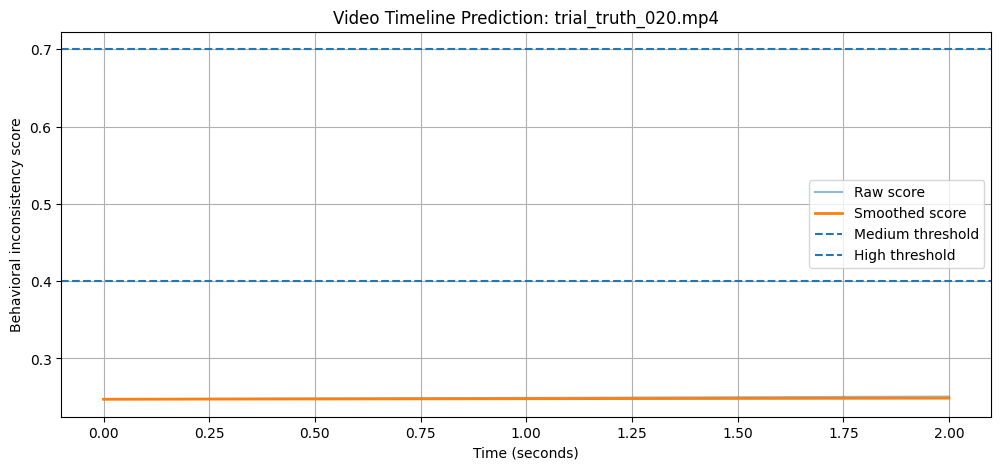

In [82]:
plt.figure(figsize=(12, 5))

plt.plot(
    window_info["start_time"],
    window_info["raw_score"],
    label="Raw score",
    alpha=0.5
)

plt.plot(
    window_info["start_time"],
    window_info["smoothed_score"],
    label="Smoothed score",
    linewidth=2
)

plt.axhline(0.40, linestyle="--", label="Medium threshold")
plt.axhline(0.70, linestyle="--", label="High threshold")

plt.xlabel("Time (seconds)")
plt.ylabel("Behavioral inconsistency score")
plt.title(f"Video Timeline Prediction: {VIDEO_PATH.name}")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
high_risk_segments = window_info[window_info["risk"] == "high"]

if len(high_risk_segments) == 0:
    print("No high-risk segments detected.")
else:
    display(
        high_risk_segments[
            ["window_index", "start_time", "end_time", "raw_score", "smoothed_score", "risk"]
        ]
    )

No high-risk segments detected.


In [84]:
def predict_video_timeline(video_path):
    video_path = Path(video_path)

    sequence, valid_frame_indices, metadata = extract_landmark_sequence_from_video(
        video_path,
        target_fps=TARGET_FPS
    )

    if sequence.shape[1] != FEATURE_DIM:
        raise ValueError(
            f"Feature dimension mismatch. Model expects {FEATURE_DIM}, "
            f"but extracted sequence has {sequence.shape[1]}."
        )

    X_infer, window_info = create_inference_windows(
        sequence,
        window_size=WINDOW_SIZE,
        stride=STRIDE
    )

    window_info = add_timestamp_columns(
        window_info,
        target_fps=TARGET_FPS
    )

    raw_scores = model.predict(X_infer).ravel()

    window_info["raw_score"] = raw_scores
    window_info["smoothed_score"] = smooth_scores(raw_scores, alpha=0.6)
    window_info["risk"] = window_info["smoothed_score"].apply(assign_risk)

    overall_score = float(window_info["smoothed_score"].mean())
    overall_risk = assign_risk(overall_score)

    timeline = []

    for _, row in window_info.iterrows():
        timeline.append({
            "window_index": int(row["window_index"]),
            "start": round(float(row["start_time"]), 2),
            "end": round(float(row["end_time"]), 2),
            "raw_score": round(float(row["raw_score"]), 4),
            "smoothed_score": round(float(row["smoothed_score"]), 4),
            "risk": row["risk"]
        })

    return {
        "video_name": video_path.name,
        "overall_score": round(overall_score, 4),
        "overall_risk": overall_risk,
        "metadata": metadata,
        "timeline": timeline
    }

In [85]:
test_result = predict_video_timeline(VIDEO_PATH)

print("Video:", test_result["video_name"])
print("Overall score:", test_result["overall_score"])
print("Overall risk:", test_result["overall_risk"])
print("First 3 timeline items:")
test_result["timeline"][:3]

Extracting landmarks: trial_truth_020.mp4: 100%|██████████| 35/35 [00:00<00:00, 93.68it/s]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Video: trial_truth_020.mp4
Overall score: 0.2479
Overall risk: low
First 3 timeline items:


[{'window_index': 0,
  'start': 0.0,
  'end': 5.0,
  'raw_score': 0.2472,
  'smoothed_score': 0.2472,
  'risk': 'low'},
 {'window_index': 1,
  'start': 2.0,
  'end': 7.0,
  'raw_score': 0.2506,
  'smoothed_score': 0.2486,
  'risk': 'low'}]